### Import packages

In [1]:

import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier
from xgboost import plot_importance
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import plot_tree
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, fbeta_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import to_graphviz
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.feature_selection import RFECV,SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, roc_auc_score
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.getcwd()
os.chdir('/content/drive/MyDrive/GTU/DSAN5300/dsan5300_group1_final_project/')

### BNPL1


#### Data preprocessing

In [4]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/tmp/ipykernel_33719/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [5]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL1']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data[c] = data[c].map(map_cols1)

In [6]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data[c], prefix=c).astype(int)

data = pd.concat([data, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [7]:
# drop columns
data_cleaned = data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C', # remove original columns due to OHE
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])


In [8]:
# independent variables
X = data_cleaned.drop(columns=['BNPL1'])
# target variable
y = data_cleaned['BNPL1']

# weights
weights = data_cleaned['weight']

In [9]:
# train, test split
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

# resampling train fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_val_res = X_val["weight"].values
X_val_res = X_val.drop(columns=["weight"])

w_test_res = X_test["weight"].values
X_test_res = X_test.drop(columns=["weight"])


In [10]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017"]

scaler = StandardScaler()

X_train_res[numeric_cols] = scaler.fit_transform(X_train_res[numeric_cols])
X_val_res[numeric_cols] = scaler.transform(X_val_res[numeric_cols])
X_test_res[numeric_cols] = scaler.transform(X_test_res[numeric_cols])

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(pd.DataFrame([c, X_test_res[c].unique()] for c in X_train_res.columns))
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,0,1
0,EF3_a,"[0, 1]"
1,EF3_b,"[1, 0]"
2,EF3_c,"[0, 1]"
3,EF3_d,"[0, 1]"
4,EF3_e,"[0, 1]"
5,EF3_f,"[0, 1]"
6,EF3_g,"[0, 1]"
7,EF3_h,"[0, 1]"
8,ppage,"[1.5049763863104857, -0.8206975767664674, 0.40..."
9,ppgender,"[1, 0]"


#### Build model

In [11]:
# model
model = models.Sequential([
    # Input Layer + First Hidden Layer
    layers.Dense(128, activation='relu', input_shape=(X_train_res.shape[1],)),
#    layers.Dropout(0.2),  # Randomly shuts off 20% of neurons to prevent memorization

    # Second Hidden Layer
    layers.Dense(64, activation='relu'),
#    layers.Dropout(0.1),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

# compile the Model
custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(
    optimizer=custom_optimizer,
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

# early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train the model

In [12]:
# train the Model
history = model.fit(
    X_train_res,
    y_train_res,
    validation_data=(X_val_res, y_val),
    sample_weight=w_train_res,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
835/835 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6789 - auc: 0.7423 - loss: 0.6243 - val_accuracy: 0.6863 - val_auc: 0.7463 - val_loss: 0.5780
Epoch 2/50
835/835 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7073 - auc: 0.7775 - loss: 0.5866 - val_accuracy: 0.6975 - val_auc: 0.7522 - val_loss: 0.5656
Epoch 3/50
835/835 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7111 - auc: 0.7851 - loss: 0.5769 - val_accuracy: 0.6928 - val_auc: 0.7535 - val_loss: 0.5746
Epoch 4/50
835/835 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7164 - auc: 0.7908 - loss: 0.5695 - val_accuracy: 0.7117 - val_auc: 0.7540 - val_loss: 0.5517
Epoch 5/50
835/835 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7212 - auc: 0.7961 - loss: 0.5624 - val_accuracy: 0.7024 - val_auc: 0.7533 - val_loss: 0.5665
Epoch 6/50
835/835 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7254 - auc: 0.8012 - loss: 0.5554 - val_accuracy: 0.7096 - val_auc: 0.7532 - val_loss: 0.5587
Epoch 7/50
835/835 ━━━━━━━━━━━━━━━━━━━━ 

#### Report validation results

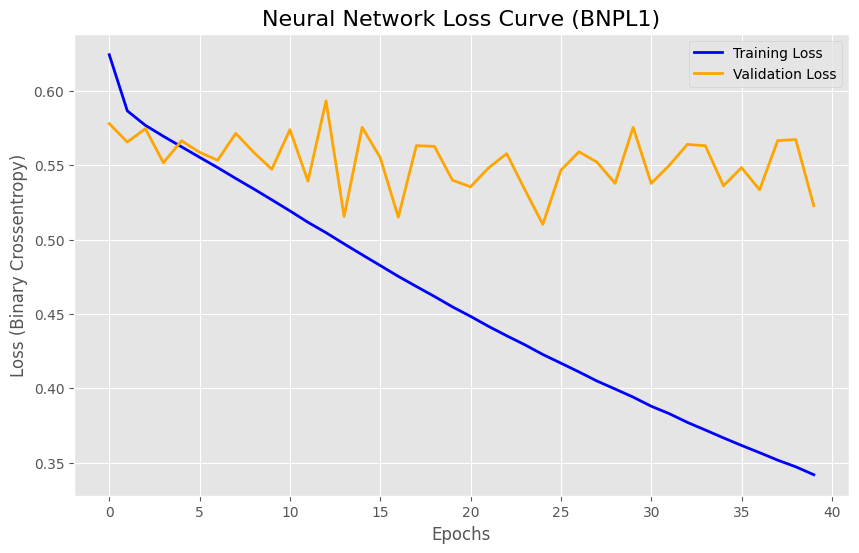

<Figure size 640x480 with 0 Axes>

In [13]:
# plot train and validation loss
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)

plt.title('Neural Network Loss Curve (BNPL1)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Binary Crossentropy)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('NN_loss_curve_BNPL1.png')

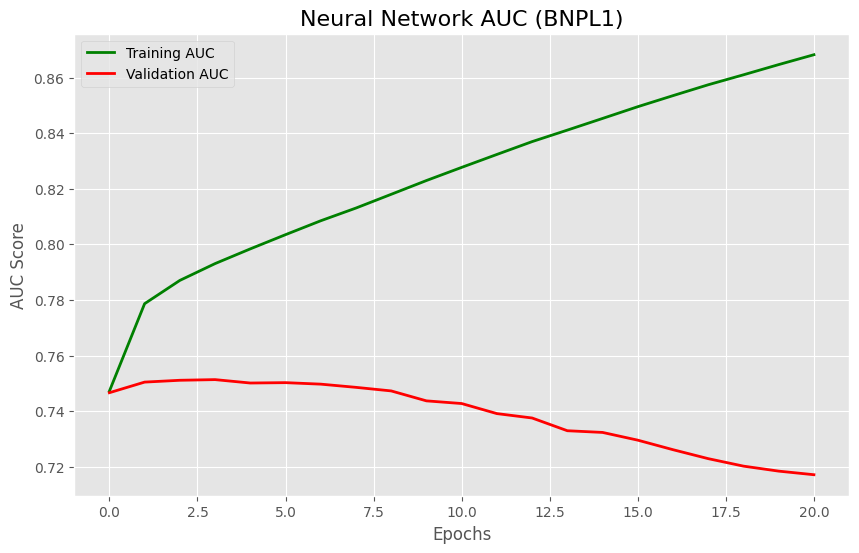

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot train and validation auc
plt.figure(figsize=(10, 6))

plt.plot(history.history['auc'], label='Training AUC', color='green', lw=2)
plt.plot(history.history['val_auc'], label='Validation AUC', color='red', lw=2)

plt.title('Neural Network AUC (BNPL1)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend()
plt.show()
plt.savefig('NN_auc_curve_BNPL1.png')

#### Test accuracy


In [14]:
# evaluate the model on the Test Set
test_results = model.evaluate(X_test_res, y_test, verbose=0)

print(f"--- FINAL TEST RESULTS ---")
print(f"Test Loss:     {test_results[0]:.4f}")
print(f"Test AUC:      {test_results[1]:.4f}")
print(f"Test Accuracy: {test_results[2]:.4f}")


y_probs = model.predict(X_test_res).flatten()
y_preds = (y_probs > 0.5).astype(int) # Standard 0.5 threshold

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_preds))

--- FINAL TEST RESULTS ---
Test Loss:     0.4930
Test AUC:      0.7259
Test Accuracy: 0.7675
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      8346
           1       0.25      0.51      0.34      1102

    accuracy                           0.77      9448
   macro avg       0.59      0.65      0.60      9448
weighted avg       0.85      0.77      0.80      9448



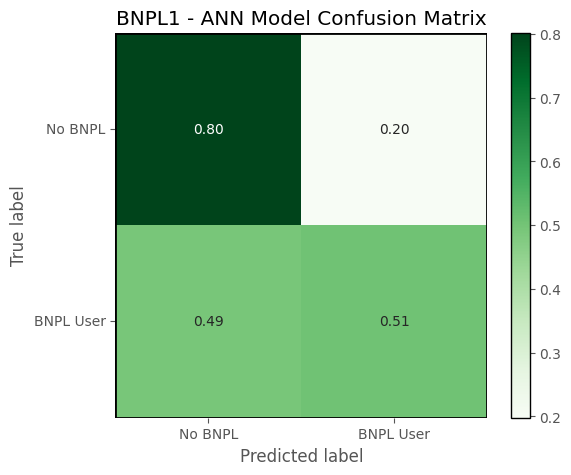

In [15]:

cm_nn_BNPL1 = confusion_matrix(y_test, y_preds, normalize='true')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    cm_nn_BNPL1,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=['No BNPL', 'BNPL User'],
    yticklabels=['No BNPL', 'BNPL User']
)

plt.yticks(rotation=0)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', lw=2))

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BNPL1 - ANN Model Confusion Matrix")
plt.show()

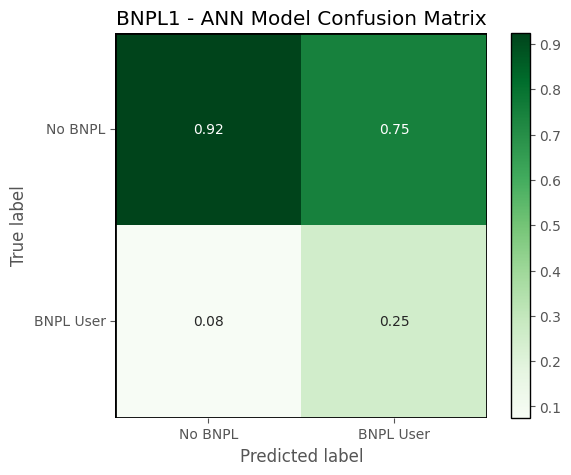

In [16]:

cm_nn_BNPL1 = confusion_matrix(y_test, y_preds, normalize='pred')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    cm_nn_BNPL1,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=['No BNPL', 'BNPL User'],
    yticklabels=['No BNPL', 'BNPL User']
)

plt.yticks(rotation=0)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', lw=2))

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BNPL1 - ANN Model Confusion Matrix")
plt.show()

### BNPL3

#### Data pre-processing

In [17]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/tmp/ipykernel_33719/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [18]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL3']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data[c] = data[c].map(map_cols1)

In [19]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data[c], prefix=c).astype(int)

data = pd.concat([data, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [20]:
# drop columns
data_cleaned = data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                                  'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])

In [21]:
data_cleaned = data_cleaned.dropna()

In [22]:
# independent variables
X = data_cleaned.drop(columns=['BNPL3'])
# target variable
y = data_cleaned['BNPL3']

# weights
weights = data_cleaned['weight']

In [23]:
# train, test split
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

# resampling train fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_val_res = X_val["weight"].values
X_val_res = X_val.drop(columns=["weight"])

w_test_res = X_test["weight"].values
X_test_res = X_test.drop(columns=["weight"])


In [24]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017"]

scaler = StandardScaler()

X_train_res[numeric_cols] = scaler.fit_transform(X_train_res[numeric_cols])
X_val_res[numeric_cols] = scaler.transform(X_val_res[numeric_cols])
X_test_res[numeric_cols] = scaler.transform(X_test_res[numeric_cols])

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(pd.DataFrame([c, X_test_res[c].unique()] for c in X_train_res.columns))
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,0,1
0,EF3_a,"[1, 0]"
1,EF3_b,"[1, 0]"
2,EF3_c,"[1, 0]"
3,EF3_d,"[0, 1]"
4,EF3_e,"[0, 1]"
5,EF3_f,"[0, 1]"
6,EF3_g,"[0, 1]"
7,EF3_h,"[0, 1]"
8,ppage,"[1.7699403847629254, -0.9598841353237608, -1.2..."
9,ppgender,"[1, 0]"


#### Build model

In [25]:
# model
model = models.Sequential([
    # Input Layer + First Hidden Layer
    layers.Dense(128, activation='relu', input_shape=(X_train_res.shape[1],)),
#    layers.Dropout(0.2),  # Randomly shuts off 20% of neurons to prevent memorization

    # Second Hidden Layer
    layers.Dense(64, activation='relu'),
#    layers.Dropout(0.1),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

# compile the Model
custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(
    optimizer=custom_optimizer,
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

# early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Train the model

In [26]:
# train the Model
history = model.fit(
    X_train_res,
    y_train_res,
    validation_data=(X_val_res, y_val),
    sample_weight=w_train_res,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6489 - auc: 0.7128 - loss: 0.7122 - val_accuracy: 0.6587 - val_auc: 0.7246 - val_loss: 0.6302
Epoch 2/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7089 - auc: 0.7830 - loss: 0.6443 - val_accuracy: 0.6950 - val_auc: 0.7470 - val_loss: 0.5810
Epoch 3/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7287 - auc: 0.8008 - loss: 0.6097 - val_accuracy: 0.6950 - val_auc: 0.7546 - val_loss: 0.5600
Epoch 4/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7452 - auc: 0.8133 - loss: 0.5906 - val_accuracy: 0.6927 - val_auc: 0.7580 - val_loss: 0.5672
Epoch 5/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7543 - auc: 0.8215 - loss: 0.5760 - val_accuracy: 0.6950 - val_auc: 0.7597 - val_loss: 0.5682
Epoch 6/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7564 - auc: 0.8300 - loss: 0.5626 - val_accuracy: 0.6961 - val_auc: 0.7610 - val_loss: 0.5753
Epoch 7/100
182/182 ━━━━━━━━━━━━━

#### Report validation loss

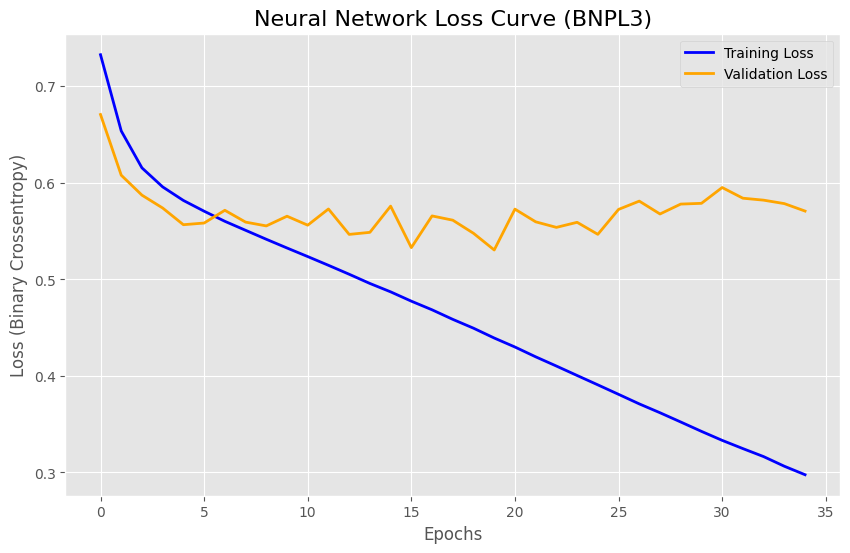

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot train and validation loss
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)

plt.title('Neural Network Loss Curve (BNPL3)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Binary Crossentropy)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('NN_loss_curve_BNPL3.png')

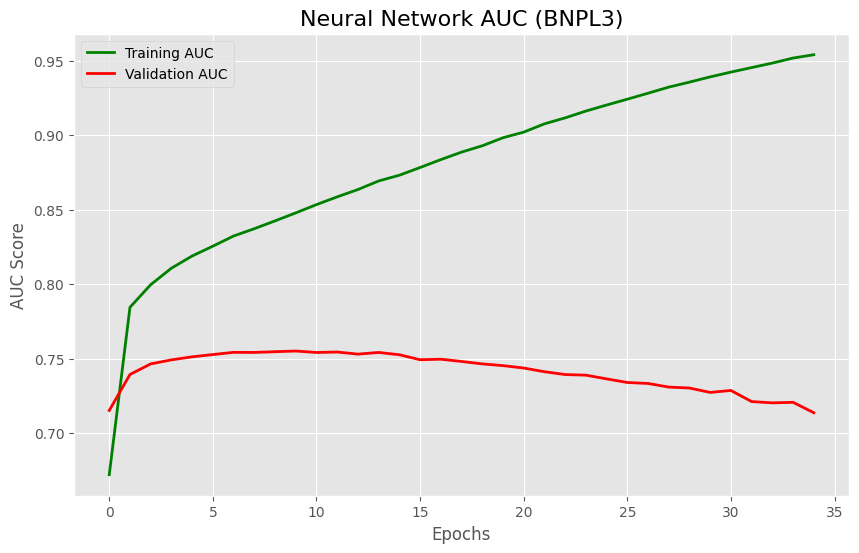

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot train and validation auc
plt.figure(figsize=(10, 6))

plt.plot(history.history['auc'], label='Training AUC', color='green', lw=2)
plt.plot(history.history['val_auc'], label='Validation AUC', color='red', lw=2)

plt.title('Neural Network AUC (BNPL3)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend()
plt.show()
plt.savefig('NN_auc_curve_BNPL3.png')

Test accuracy

In [27]:
# evaluate the model on the Test Set
test_results = model.evaluate(X_test_res, y_test, verbose=0)

print(f"--- FINAL TEST RESULTS ---")
print(f"Test Loss:     {test_results[0]:.4f}")
print(f"Test AUC:      {test_results[1]:.4f}")
print(f"Test Accuracy: {test_results[2]:.4f}")


y_probs = model.predict(X_test_res).flatten()
y_preds = (y_probs > 0.5).astype(int) # Standard 0.5 threshold

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_preds))

--- FINAL TEST RESULTS ---
Test Loss:     0.5331
Test AUC:      0.7460
Test Accuracy: 0.7235
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82       909
         1.0       0.34      0.59      0.43       194

    accuracy                           0.72      1103
   macro avg       0.62      0.67      0.62      1103
weighted avg       0.80      0.72      0.75      1103



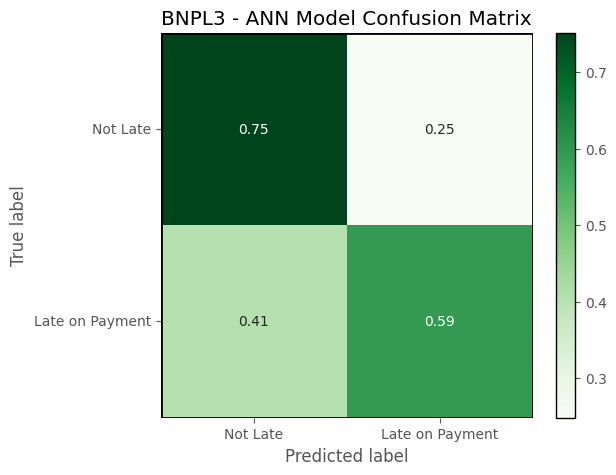

In [30]:

cm_nn_BNPL3 = confusion_matrix(y_test, y_preds, normalize='true')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    cm_nn_BNPL3,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=['Not Late', 'Late on Payment'],
    yticklabels=['Not Late', 'Late on Payment']
)
plt.yticks(rotation=0)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', lw=2))

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BNPL3 - ANN Model Confusion Matrix")
plt.show()

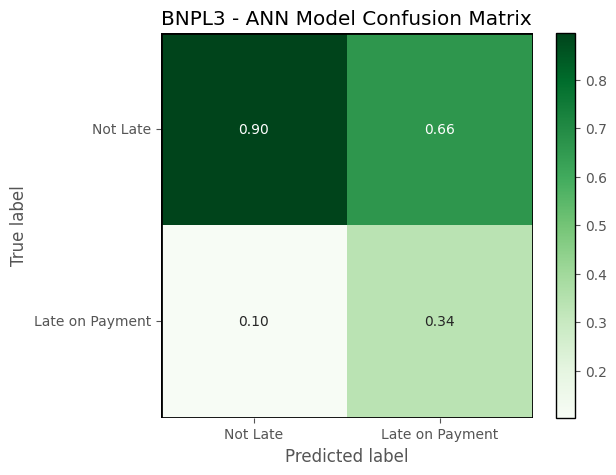

In [31]:

cm_nn_BNPL3 = confusion_matrix(y_test, y_preds, normalize='pred')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    cm_nn_BNPL3,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=['Not Late', 'Late on Payment'],
    yticklabels=['Not Late', 'Late on Payment']
)
plt.yticks(rotation=0)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', lw=2))

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BNPL3 - ANN Model Confusion Matrix")
plt.show()

### BNPL1 2024

#### Data pre-processing

In [ ]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]
data_2024 = data.loc[data['year']==2024]

/tmp/ipykernel_3409/2448053278.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [ ]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL1']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data_2024[c] = data_2024[c].map(map_cols1)

/tmp/ipykernel_3409/1665977338.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024[c] = data_2024[c].map(map_cols1)
/tmp/ipykernel_3409/1665977338.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024[c] = data_2024[c].map(map_cols1)
/tmp/ipykernel_3409/1665977338.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

In [ ]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data_2024[c], prefix=c).astype(int)

data_2024 = pd.concat([data_2024, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [ ]:
# multi-class to ordinal
cols3 = ['X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

map_cols3 = ({
    'Not a concern': 0,
    'Minor concern': 1,
    'Major concern': 2
})

for c in cols3:
  data_2024[c] = data_2024[c].map(map_cols3)

In [ ]:
# drop columns
data2024_cleaned = data_2024.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                      'I41_c','I41_e', 'SL6', 'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C'])

In [ ]:
# drop nas
data_2024_cleaned = data2024_cleaned.dropna()

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
data_2024_cleaned.isna().sum()

,0
weight,0
BNPL1,0
EF3_a,0
EF3_b,0
EF3_c,0
EF3_d,0
EF3_e,0
EF3_f,0
EF3_g,0
EF3_h,0


In [ ]:
display(pd.DataFrame([c, data_2024_cleaned[c].unique()] for c in data_2024_cleaned.columns))

,0,1
0,weight,"[0.9064, 0.5601, 0.6871, 1.042, 1.2567, 0.9613..."
1,BNPL1,"[0, 1]"
2,EF3_a,"[1, 0]"
3,EF3_b,"[0, 1]"
4,EF3_c,"[0, 1]"
5,EF3_d,"[0, 1]"
6,EF3_e,"[0, 1]"
7,EF3_f,"[0, 1]"
8,EF3_g,"[0, 1]"
9,EF3_h,"[0, 1]"


In [ ]:
# independent variables
X = data_2024_cleaned.drop(columns=['BNPL1'])
# target variable
y = data_2024_cleaned['BNPL1']

# weights
weights = data_2024_cleaned['weight']

In [ ]:
# train, test split
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

# resampling train fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_val_res = X_val["weight"].values
X_val_res = X_val.drop(columns=["weight"])

w_test_res = X_test["weight"].values
X_test_res = X_test.drop(columns=["weight"])


In [ ]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017",'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

scaler = StandardScaler()

X_train_res[numeric_cols] = scaler.fit_transform(X_train_res[numeric_cols])
X_val_res[numeric_cols] = scaler.transform(X_val_res[numeric_cols])
X_test_res[numeric_cols] = scaler.transform(X_test_res[numeric_cols])

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(pd.DataFrame([c, X_test_res[c].unique()] for c in X_train_res.columns))
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,0,1
0,EF3_a,"[0, 1]"
1,EF3_b,"[0, 1]"
2,EF3_c,"[0, 1]"
3,EF3_d,"[0, 1]"
4,EF3_e,"[0, 1]"
5,EF3_f,"[0, 1]"
6,EF3_g,"[0, 1]"
7,EF3_h,"[1, 0]"
8,ppage,"[-1.4975986299751547, -0.42352587695544175, -0..."
9,ppgender,"[1, 0]"


#### Build model

In [ ]:
# model
model = models.Sequential([
    # Input Layer + First Hidden Layer
    layers.Dense(128, activation='relu', input_shape=(X_train_res.shape[1],)),
#    layers.Dropout(0.2),  # Randomly shuts off 20% of neurons to prevent memorization

    # Second Hidden Layer
    layers.Dense(64, activation='relu'),
#    layers.Dropout(0.1),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

# compile the Model
custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(
    optimizer=custom_optimizer,
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

# early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Train the model

In [ ]:
# train the Model
history = model.fit(
    X_train_res,
    y_train_res,
    validation_data=(X_val_res, y_val),
    sample_weight=w_train_res,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5268 - auc: 0.5365 - loss: 0.7285 - val_accuracy: 0.4954 - val_auc: 0.6432 - val_loss: 0.7177
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6161 - auc: 0.6598 - loss: 0.6773 - val_accuracy: 0.6738 - val_auc: 0.7001 - val_loss: 0.6492
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6518 - auc: 0.7134 - loss: 0.6488 - val_accuracy: 0.6738 - val_auc: 0.7268 - val_loss: 0.6252
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6791 - auc: 0.7415 - loss: 0.6282 - val_accuracy: 0.6585 - val_auc: 0.7395 - val_loss: 0.6078
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6979 - auc: 0.7585 - loss: 0.6120 - val_accuracy: 0.6646 - val_auc: 0.7432 - val_loss: 0.5977
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7073 - auc: 0.7730 - loss: 0.5978 - val_accuracy: 0.6862 - val_auc: 0.7449 - val_loss: 0.5875
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms

#### Report validation results

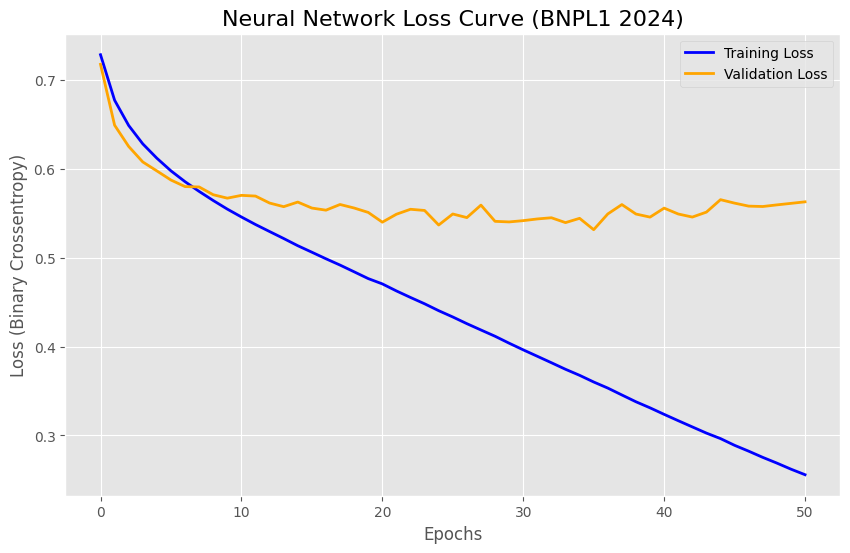

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot train and validation loss
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)

plt.title('Neural Network Loss Curve (BNPL1 2024)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Binary Crossentropy)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('NN_loss_curve_BNPL1_2024.png')

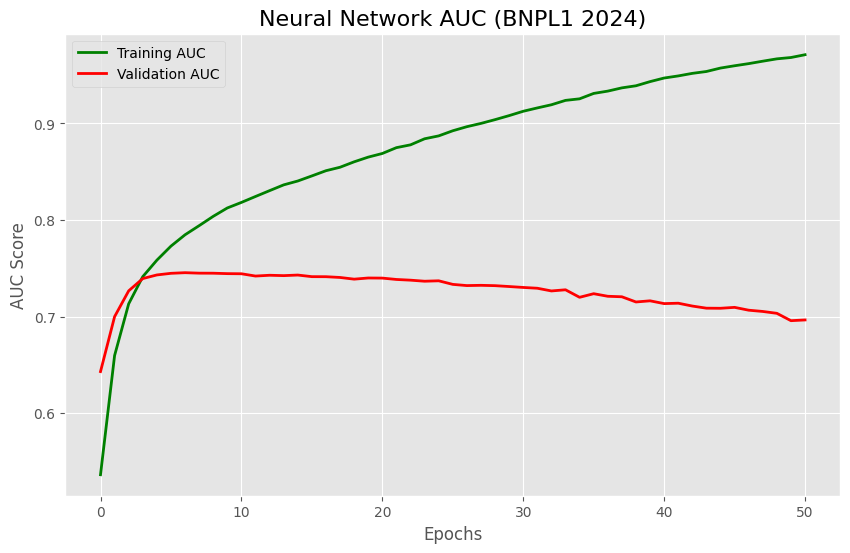

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot train and validation auc
plt.figure(figsize=(10, 6))

plt.plot(history.history['auc'], label='Training AUC', color='green', lw=2)
plt.plot(history.history['val_auc'], label='Validation AUC', color='red', lw=2)

plt.title('Neural Network AUC (BNPL1 2024)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend()
plt.show()
plt.savefig('NN_auc_curve_BNPL1_2024.png')

#### Test accuracy

In [ ]:
# evaluate the model on the Test Set
test_results = model.evaluate(X_test_res, y_test, verbose=0)

print(f"--- FINAL TEST RESULTS ---")
print(f"Test Loss:     {test_results[0]:.4f}")
print(f"Test AUC:      {test_results[1]:.4f}")
print(f"Test Accuracy: {test_results[2]:.4f}")


y_probs = model.predict(X_test_res).flatten()
y_preds = (y_probs > 0.5).astype(int) # Standard 0.5 threshold

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_preds))

--- FINAL TEST RESULTS ---
Test Loss:     0.5796
Test AUC:      0.7040
Test Accuracy: 0.7076
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       316
           1       0.39      0.55      0.46        91

    accuracy                           0.71       407
   macro avg       0.62      0.65      0.63       407
weighted avg       0.75      0.71      0.72       407



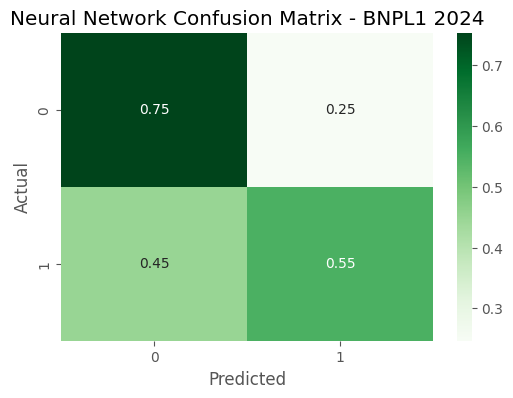

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_preds, normalize='true')
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,  cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix - BNPL1 2024')
plt.show()